# Análise Inicial dos Dados – TelecomX Churn

Este notebook realiza uma análise exploratória inicial do dataset da TelecomX
com foco em entender a estrutura dos dados e identificar possíveis fatores
relacionados à evasão de clientes (churn).

Objetivos desta etapa:

- compreender a estrutura do dataset
- analisar a distribuição da variável churn
- identificar relações entre variáveis
- levantar hipóteses para a modelagem preditiva

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

# Configurações de visualização
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')
plt.rcParams['figure.figsize'] = (12, 6)

# Importar módulos do projeto
import sys
sys.path.insert(0, '../')
from src.data.eda import (
    load_data, basic_info, analyze_target_variable,
    numeric_features_summary, categorical_features_summary,
    check_data_quality
)

In [2]:
# Carregar dados
df = load_data('../data/processed/dados_tratados.csv')

print(f"\n✅ Dataset carregado com sucesso!")
print(f"Dimensões: {df.shape[0]:,} linhas × {df.shape[1]} colunas")


✅ Dataset carregado com sucesso!
Dimensões: 7,267 linhas × 21 colunas


In [3]:
# Obter informações básicas
info = basic_info(df)

print("\n" + "="*80)
print("INFORMAÇÕES BÁSICAS DO DATASET")
print("="*80)

print(f"\nDimensões: {info['shape'][0]:,} linhas × {info['shape'][1]} colunas")

print(f"\nTipos de Dados:")
for dtype, count in pd.Series(info['dtypes']).value_counts().items():
    print(f"  - {dtype}: {count} colunas")

print(f"\nDuplicatas: {info['duplicates']}")

print(f"\nColunas:")
for i, col in enumerate(info['columns'], 1):
    print(f"  {i:2d}. {col}")


INFORMAÇÕES BÁSICAS DO DATASET

Dimensões: 7,267 linhas × 21 colunas

Tipos de Dados:
  - str: 17 colunas
  - int64: 2 colunas
  - float64: 2 colunas

Duplicatas: 0

Colunas:
   1. customerid
   2. churn
   3. customer_gender
   4. customer_seniorcitizen
   5. customer_partner
   6. customer_dependents
   7. customer_tenure
   8. phone_phoneservice
   9. phone_multiplelines
  10. internet_internetservice
  11. internet_onlinesecurity
  12. internet_onlinebackup
  13. internet_deviceprotection
  14. internet_techsupport
  15. internet_streamingtv
  16. internet_streamingmovies
  17. account_contract
  18. account_paperlessbilling
  19. account_paymentmethod
  20. account_charges_monthly
  21. account_charges_total


In [4]:
# Verificar qualidade dos dados
quality = check_data_quality(df)

print("\n" + "="*80)
print("QUALIDADE DOS DADOS")
print("="*80)

print(f"\nTotal de Linhas: {quality['total_rows']:,}")
print(f"Total de Valores Nulos: {quality['null_values']}")
print(f"Percentual de Nulos: {quality['null_percentage']:.2f}%")
print(f"Duplicatas: {quality['duplicates']}")

if quality['columns_with_nulls']:
    print(f"\n⚠️ Colunas com Valores Nulos:")
    for col in quality['columns_with_nulls']:
        null_count = df[col].isnull().sum()
        null_pct = (null_count / len(df)) * 100
        print(f"  - {col}: {null_count} ({null_pct:.2f}%)")
else:
    print(f"\n✅ Nenhuma coluna com valores nulos")


QUALIDADE DOS DADOS

Total de Linhas: 7,267
Total de Valores Nulos: 235
Percentual de Nulos: 0.15%
Duplicatas: 0

⚠️ Colunas com Valores Nulos:
  - churn: 224 (3.08%)
  - account_charges_total: 11 (0.15%)


In [5]:
# Analisar target
target_analysis = analyze_target_variable(df)

print("\n" + "="*80)
print("ANÁLISE DA VARIÁVEL ALVO - CHURN")
print("="*80)

print(f"\nDistribuição Absoluta:")
for class_name, count in target_analysis['distribution'].items():
    print(f"  {class_name}: {count:,} clientes")

print(f"\nDistribuição Relativa:")
for class_name, prop in target_analysis['proportions'].items():
    print(f"  {class_name}: {prop*100:.2f}%")

print(f"\n⚠️ Proporção da Classe Minoritária: {target_analysis['imbalance_ratio']*100:.2f}%")
print(f"   (Desequilíbrio Moderado - Será necessário balanceamento)")


ANÁLISE DA VARIÁVEL ALVO - CHURN

Distribuição Absoluta:
  No: 5,174 clientes
  Yes: 1,869 clientes

Distribuição Relativa:
  No: 73.46%
  Yes: 26.54%

⚠️ Proporção da Classe Minoritária: 26.54%
   (Desequilíbrio Moderado - Será necessário balanceamento)


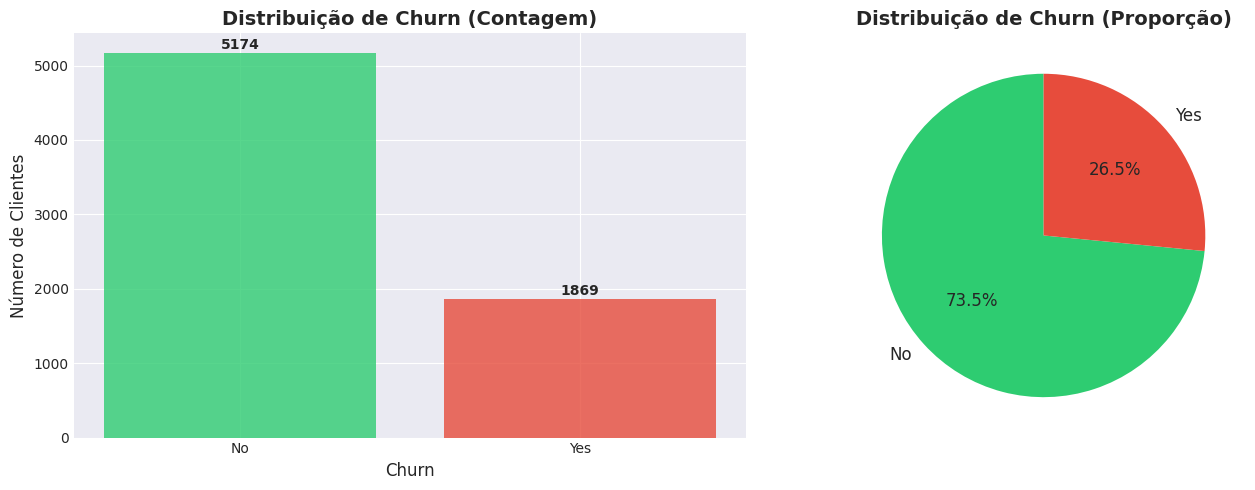

In [6]:
# Visualizar distribuição de churn
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Contagem
churn_counts = df['churn'].value_counts()
axes[0].bar(churn_counts.index, churn_counts.values, color=['#2ecc71', '#e74c3c'], alpha=0.8)
axes[0].set_title('Distribuição de Churn (Contagem)', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Número de Clientes', fontsize=12)
axes[0].set_xlabel('Churn', fontsize=12)
for i, v in enumerate(churn_counts.values):
    axes[0].text(i, v + 50, str(v), ha='center', fontweight='bold')

# Proporção
churn_prop = df['churn'].value_counts(normalize=True)
colors = ['#2ecc71', '#e74c3c']
axes[1].pie(churn_prop.values, labels=churn_prop.index, autopct='%1.1f%%',
           colors=colors, startangle=90, textprops={'fontsize': 12})
axes[1].set_title('Distribuição de Churn (Proporção)', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

In [7]:
# Resumo de variáveis numéricas
numeric_summary = numeric_features_summary(df)

print("\n" + "="*80)
print("ESTATÍSTICAS DESCRITIVAS - VARIÁVEIS NUMÉRICAS")
print("="*80)
print(numeric_summary.round(2))


ESTATÍSTICAS DESCRITIVAS - VARIÁVEIS NUMÉRICAS
       customer_seniorcitizen  customer_tenure  account_charges_monthly  \
count                 7267.00          7267.00                  7267.00   
mean                     0.16            32.35                    64.72   
std                      0.37            24.57                    30.13   
min                      0.00             0.00                    18.25   
25%                      0.00             9.00                    35.42   
50%                      0.00            29.00                    70.30   
75%                      0.00            55.00                    89.88   
max                      1.00            72.00                   118.75   

       account_charges_total  
count                7256.00  
mean                 2280.63  
std                  2268.63  
min                    18.80  
25%                   400.22  
50%                  1391.00  
75%                  3785.30  
max                  8684.80

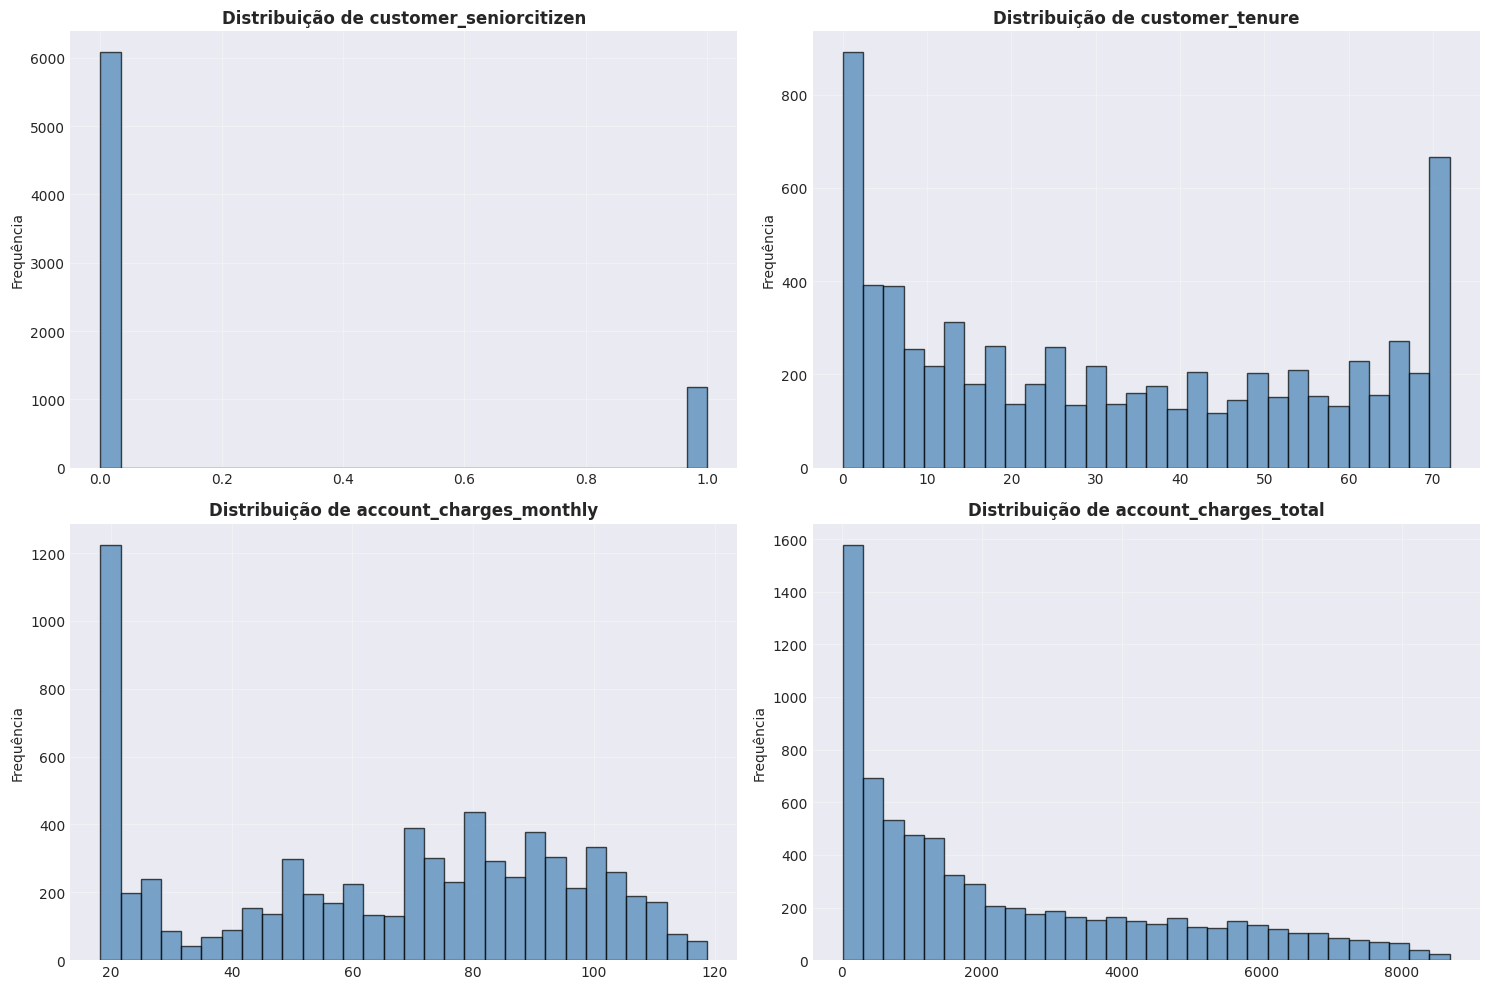

In [8]:
# Distribuição de variáveis numéricas
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()

fig, axes = plt.subplots(2, 2, figsize=(15, 10))
axes = axes.flatten()

for idx, col in enumerate(numeric_cols):
    axes[idx].hist(df[col].dropna(), bins=30, color='steelblue', alpha=0.7, edgecolor='black')
    axes[idx].set_title(f'Distribuição de {col}', fontsize=12, fontweight='bold')
    axes[idx].set_ylabel('Frequência', fontsize=10)
    axes[idx].grid(alpha=0.3)

plt.tight_layout()
plt.show()

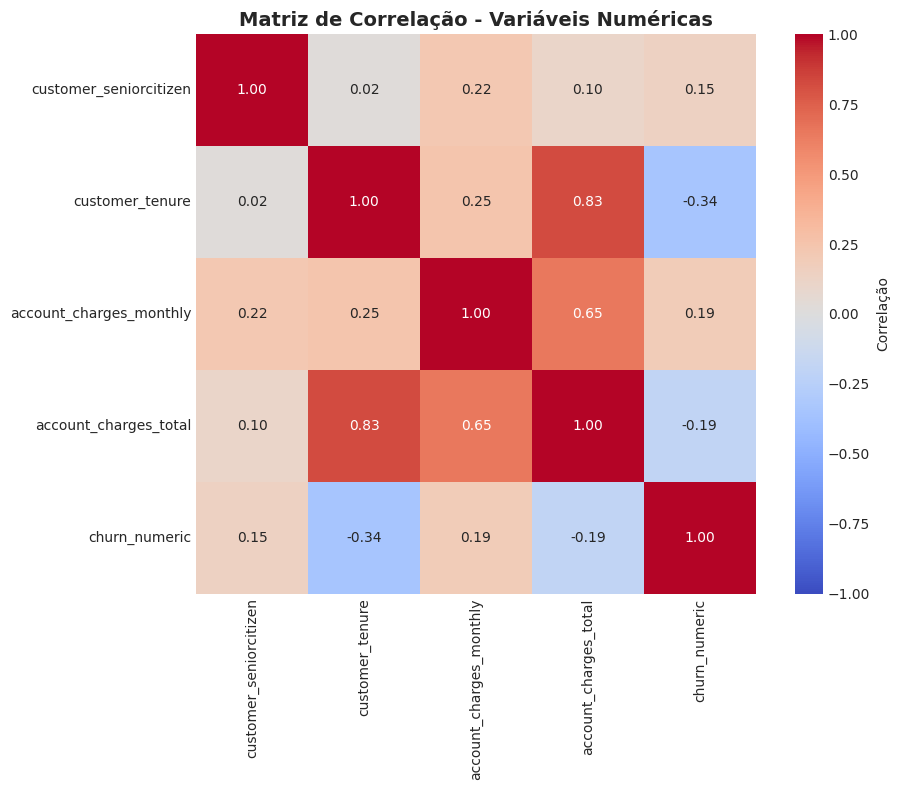

In [9]:
# Preparar dados para correlação
df_numeric = df.select_dtypes(include=[np.number]).copy()

# Converter churn para numérico
df_numeric['churn_numeric'] = (df['churn'] == 'Yes').astype(int)

# Calcular correlação
correlation_matrix = df_numeric.corr()

# Visualizar matriz de correlação
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm',
           square=True, cbar_kws={'label': 'Correlação'}, vmin=-1, vmax=1, center=0)
plt.title('Matriz de Correlação - Variáveis Numéricas', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [10]:
# Correlação de cada variável com churn
churn_numeric = (df['churn'] == 'Yes').astype(int)
numeric_cols_only = df.select_dtypes(include=[np.number]).columns.tolist()

# Calcular correlações
correlations_with_churn = {}
for col in numeric_cols_only:
    corr = df[col].corr(churn_numeric)
    correlations_with_churn[col] = corr

# Ordenar por valor absoluto
corr_df = pd.DataFrame.from_dict(correlations_with_churn, orient='index', columns=['Correlation'])
corr_df = corr_df.sort_values('Correlation', key=abs, ascending=False)

print("\n" + "="*80)
print("CORRELAÇÃO DAS VARIÁVEIS COM CHURN")
print("="*80)
print(corr_df.round(4))


CORRELAÇÃO DAS VARIÁVEIS COM CHURN
                         Correlation
customer_tenure              -0.3441
account_charges_total        -0.1944
account_charges_monthly       0.1899
customer_seniorcitizen        0.1467


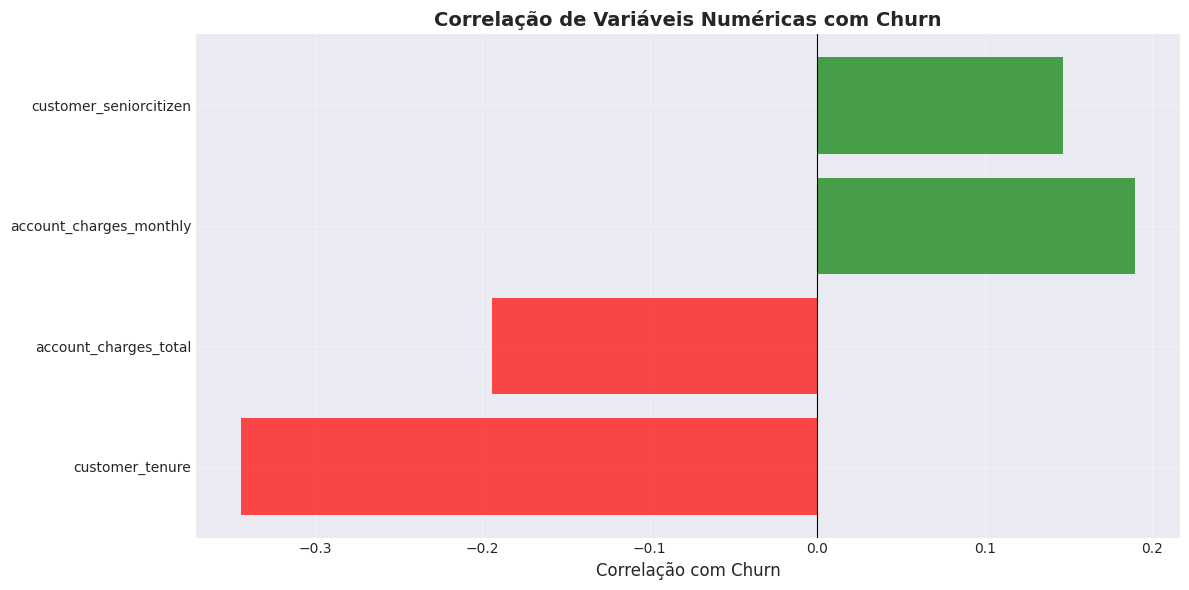

In [11]:
# Visualizar correlações
plt.figure(figsize=(12, 6))
colors = ['green' if x > 0 else 'red' for x in corr_df['Correlation']]
plt.barh(corr_df.index, corr_df['Correlation'], color=colors, alpha=0.7)
plt.xlabel('Correlação com Churn', fontsize=12)
plt.title('Correlação de Variáveis Numéricas com Churn', fontsize=14, fontweight='bold')
plt.axvline(x=0, color='black', linestyle='-', linewidth=0.8)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [12]:
# Resumo de variáveis categóricas
categorical_summary = categorical_features_summary(df)

print("\n" + "="*80)
print("SUMÁRIO DE VARIÁVEIS CATEGÓRICAS")
print("="*80)

for col, values_count in categorical_summary.items():
    print(f"\n{col}:")
    for value, count in values_count.items():
        pct = (count / df[col].notna().sum()) * 100
        print(f"  {value}: {count:,} ({pct:.2f}%)")


SUMÁRIO DE VARIÁVEIS CATEGÓRICAS

customerid:
  0002-ORFBO: 1 (0.01%)
  0003-MKNFE: 1 (0.01%)
  0004-TLHLJ: 1 (0.01%)
  0011-IGKFF: 1 (0.01%)
  0013-EXCHZ: 1 (0.01%)
  0013-MHZWF: 1 (0.01%)
  0013-SMEOE: 1 (0.01%)
  0014-BMAQU: 1 (0.01%)
  0015-UOCOJ: 1 (0.01%)
  0016-QLJIS: 1 (0.01%)
  0017-DINOC: 1 (0.01%)
  0017-IUDMW: 1 (0.01%)
  0018-NYROU: 1 (0.01%)
  0019-EFAEP: 1 (0.01%)
  0019-GFNTW: 1 (0.01%)
  0020-INWCK: 1 (0.01%)
  0020-JDNXP: 1 (0.01%)
  0021-IKXGC: 1 (0.01%)
  0022-TCJCI: 1 (0.01%)
  0023-HGHWL: 1 (0.01%)
  0023-UYUPN: 1 (0.01%)
  0023-XUOPT: 1 (0.01%)
  0027-KWYKW: 1 (0.01%)
  0030-FNXPP: 1 (0.01%)
  0031-PVLZI: 1 (0.01%)
  0032-PGELS: 1 (0.01%)
  0036-IHMOT: 1 (0.01%)
  0040-HALCW: 1 (0.01%)
  0042-JVWOJ: 1 (0.01%)
  0042-RLHYP: 1 (0.01%)
  0047-ZHDTW: 1 (0.01%)
  0048-LUMLS: 1 (0.01%)
  0048-PIHNL: 1 (0.01%)
  0052-DCKON: 1 (0.01%)
  0052-YNYOT: 1 (0.01%)
  0056-EPFBG: 1 (0.01%)
  0057-QBUQH: 1 (0.01%)
  0058-EVZWM: 1 (0.01%)
  0060-FUALY: 1 (0.01%)
  0064-SUDOG: 1 (

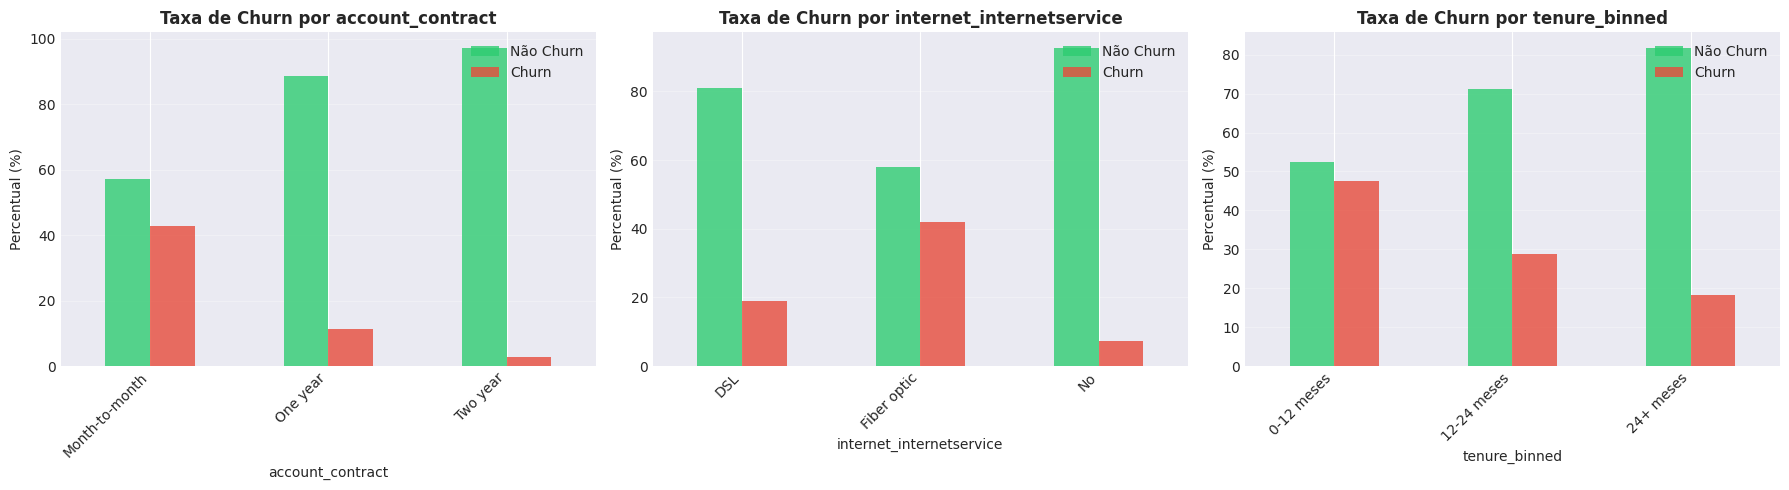

In [13]:
# Análise de churn por algumas categóricas importantes
important_cats = ['account_contract', 'internet_internetservice', 'customer_tenure']

# Tenure é numérica, então vamos binizar
df['tenure_binned'] = pd.cut(df['customer_tenure'], bins=[0, 12, 24, 60], 
                             labels=['0-12 meses', '12-24 meses', '24+ meses'])
important_cats_adj = ['account_contract', 'internet_internetservice', 'tenure_binned']

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx, col in enumerate(important_cats_adj):
    # Criar crosstab
    ct = pd.crosstab(df[col], df['churn'], normalize='index') * 100
    ct.plot(kind='bar', ax=axes[idx], color=['#2ecc71', '#e74c3c'], alpha=0.8)
    axes[idx].set_title(f'Taxa de Churn por {col}', fontsize=12, fontweight='bold')
    axes[idx].set_ylabel('Percentual (%)', fontsize=10)
    axes[idx].set_xlabel(col, fontsize=10)
    axes[idx].legend(['Não Churn', 'Churn'], loc='upper right')
    axes[idx].grid(alpha=0.3, axis='y')
    plt.setp(axes[idx].xaxis.get_majorticklabels(), rotation=45, ha='right')

plt.tight_layout()
plt.show()

In [14]:
# Resumo Executivo
print("\n" + "="*80)
print("RESUMO EXECUTIVO - ANÁLISE EXPLORATÓRIA")
print("="*80)

print("\n📊 DATASET")
print(f"  • Total de clientes: {len(df):,}")
print(f"  • Variáveis: {df.shape[1]}")
print(f"  • Valores nulos: {df.isnull().sum().sum()} ({(df.isnull().sum().sum() / (df.shape[0] * df.shape[1]) * 100):.2f}%)")


RESUMO EXECUTIVO - ANÁLISE EXPLORATÓRIA

📊 DATASET
  • Total de clientes: 7,267
  • Variáveis: 22
  • Valores nulos: 1697 (1.06%)


In [15]:
print("\n🎯 CHURN")
print(f"  • Taxa de churn: {target_analysis['proportions'].get('Yes', 0)*100:.2f}%")
print(f"  • Distribuição: 73,5% No / 26,5% Yes")
print(f"  • Status: DESEQUILÍBRIO MODERADO ⚠️ (Necessário balanceamento)")


🎯 CHURN
  • Taxa de churn: 26.54%
  • Distribuição: 73,5% No / 26,5% Yes
  • Status: DESEQUILÍBRIO MODERADO ⚠️ (Necessário balanceamento)


In [16]:
print("\n📈 VARIÁVEIS MAIS CORRELACIONADAS COM CHURN")
top_corr = corr_df.head(3)
for idx, (col, val) in enumerate(top_corr['Correlation'].items(), 1):
    print(f"  {idx}. {col}: {val:.4f}")

print("\n⚙️ PRÓXIMAS ETAPAS")
print("  1. Remover coluna 'customerid' (ID não preditivo)")
print("  2. Tratar 224 valores nulos em 'churn'")
print("  3. Tratar 11 valores nulos em 'account_charges_total'")
print("  4. Aplicar One-Hot Encoding para variáveis categóricas")
print("  5. Balancear dataset com SMOTE")
print("  6. Normalizar features (para modelos sensíveis à escala)")
print("  7. Dividir em treino/teste (80/20)")
print("  8. Construir e avaliar modelos")


📈 VARIÁVEIS MAIS CORRELACIONADAS COM CHURN
  1. customer_tenure: -0.3441
  2. account_charges_total: -0.1944
  3. account_charges_monthly: 0.1899

⚙️ PRÓXIMAS ETAPAS
  1. Remover coluna 'customerid' (ID não preditivo)
  2. Tratar 224 valores nulos em 'churn'
  3. Tratar 11 valores nulos em 'account_charges_total'
  4. Aplicar One-Hot Encoding para variáveis categóricas
  5. Balancear dataset com SMOTE
  6. Normalizar features (para modelos sensíveis à escala)
  7. Dividir em treino/teste (80/20)
  8. Construir e avaliar modelos


## Conclusões iniciais

A análise exploratória inicial revelou alguns padrões importantes:

- clientes com menor tempo de contrato apresentam maior churn
- contratos mensais apresentam maior taxa de evasão
- clientes com maiores cobranças mensais tendem a cancelar mais

Esses fatores serão considerados nas próximas etapas do projeto,
quando os dados serão preparados para a construção de modelos
preditivos de churn.

In [17]:
print("\n" + "="*80)
print("✅ CONCLUSÕES DA ANÁLISE EXPLORATÓRIA")
print("="*80)
print("\n✓ Dataset bem estruturado com 7.267 clientes e 21 variáveis")
print("✓ Classe alvo clara: Churn (Yes/No) com desequilíbrio moderado")
print("⚠ Ajustes necessários: Valores nulos em 'churn' e 'account_charges_total'")
print("→ Próximo passo: Preprocessamento e preparação para modelagem")
print("="*80)


✅ CONCLUSÕES DA ANÁLISE EXPLORATÓRIA

✓ Dataset bem estruturado com 7.267 clientes e 21 variáveis
✓ Classe alvo clara: Churn (Yes/No) com desequilíbrio moderado
⚠ Ajustes necessários: Valores nulos em 'churn' e 'account_charges_total'
→ Próximo passo: Preprocessamento e preparação para modelagem
